# KNN em Contextos de Classe Desequilibrada

---
Trabalho realizado por:

* Catarina Aguiar - 202205932
* João Raposo - 202210331
* Rodrigo Coelho - 202208009

---

Grupo: PL2_G10

## Introdução

Este trabalho prático, desenvolvido no âmbito da unidade curricular *Machine Learning I (CC2008)*, tem como objetivo aprofundar o conhecimento sobre algoritmos de classificação supervisionada, tanto do ponto de vista teórico como empírico.

O projeto consiste em implementar do zero um algoritmo de classificação, analisando o seu desempenho em presença de um desafio comum em dados reais. O desafio selecionado pelo nosso grupo foi o **desequilíbrio de classes** em problemas de **classificação binária**. O algoritmo escolhido para estudo e modificação foi o **k-Nearest Neighbors (KNN)**.

Neste notebook, será apresentado:
- O funcionamento do algoritmo KNN e a sua vulnerabilidade ao desequilíbrio de classes;
- A implementação original do algoritmo;
- As alterações propostas para mitigar o impacto do desequilíbrio;
- A comparação dos resultados obtidos com e sem as modificações, com base em conjuntos de dados de benchmark.

## Algoritmo escolhido: KNN

### Descrição técnica do KNN

O K-Nearest Neighbors (KNN) é um algoritmo de aprendizagem supervisionada baseado em instâncias, que atribui a uma nova amostra a classe mais frequente entre os seus *K* vizinhos mais próximos no espaço das features. A proximidade entre instâncias é determinada por uma métrica de distância, geralmente a distância Euclidiana, embora outras métricas possam ser utilizadas consoante o domínio do problema.

Trata-se de um algoritmo não paramétrico, que não assume qualquer modelo explícito sobre os dados e não envolve uma fase de treino propriamente dita. A complexidade computacional na fase de inferência é *O(n · d)*, onde *n* é o número de instâncias de treino e *d* o número de dimensões, o que o torna pouco escalável para grandes volumes de dados.

O desempenho do KNN é altamente influenciado pela escolha do parâmetro *K*, pela presença de ruído, pela escala das variáveis e, de forma crítica neste trabalho, por distribuições desbalanceadas de classes, nas quais a classe maioritária tende a dominar o processo de decisão.


### Fase de treino e previsão


#### Fase de Treino

O KNN é um algoritmo baseado em instâncias, o que significa que **não possui uma fase de treino tradicional** como outros algoritmos (por exemplo, árvores de decisão ou redes neuronais). Em vez disso, a "fase de treino" consiste apenas em **armazenar os dados rotulados de treino**, que serão utilizados posteriormente durante a previsão.


#### Fase de Previsão

A **fase de previsão** é computacionalmente mais intensiva, dado que para cada instância a classificar, o algoritmo calcula a distância entre essa instância e **todas as instâncias do conjunto de treino**, selecionando os *K* vizinhos mais próximos. A classe final atribuída corresponde à maioria (votação) entre os vizinhos selecionados.

Esta abordagem resulta numa complexidade de tempo de execução proporcional ao número de instâncias de treino, concretamente **O(n · d)** por previsão, sendo *n* o número de exemplos de treino e *d* o número de atributos. Este custo torna o KNN menos escalável para conjuntos de dados muito grandes ou de alta dimensionalidade.


## Bibliotecas Necessárias

Começamos por importar as bibliotecas necessárias para o tratamento e análise dos dados. Utilizamos o `pandas` para manipulação de tabelas, `numpy` para operações numéricas, e `matplotlib` e `seaborn` para visualização de dados.

In [1]:
import pandas as pd
import numpy as np
from collections import Counter
import seaborn as sns
import matplotlib.pyplot as plt
import random
from math import log2
from collections import Counter
from scipy import stats
from sklearn.metrics import confusion_matrix as cm, accuracy_score as ac, precision_score as pr, balanced_accuracy_score as bac, recall_score as rec, f1_score as f1
from sklearn.model_selection import train_test_split
from scipy.spatial.distance import euclidean
from IPython.display import display

### Código KNN

Para o desenvolvimento deste projecto, foi usado o algoritmo do KNN disponível em:
* https://github.com/rushter/MLAlgorithms

In [2]:
# Base Estimator

# coding:utf-8
class BaseEstimator:
    y_required = True
    fit_required = True

    def _setup_input(self, X, y=None):
        """Ensure inputs to an estimator are in the expected format.

        Ensures X and y are stored as numpy ndarrays by converting from an
        array-like object if necessary. Enables estimators to define whether
        they require a set of y target values or not with y_required, e.g.
        kmeans clustering requires no target labels and is fit against only X.

        Parameters
        ----------
        X : array-like
            Feature dataset.
        y : array-like
            Target values. By default is required, but if y_required = false
            then may be omitted.
        """
        if not isinstance(X, np.ndarray):
            X = np.array(X)

        if X.size == 0:
            raise ValueError("Got an empty matrix.")

        if X.ndim == 1:
            self.n_samples, self.n_features = 1, X.shape
        else:
            self.n_samples, self.n_features = X.shape[0], np.prod(X.shape[1:])

        self.X = X

        if self.y_required:
            if y is None:
                raise ValueError("Missed required argument y")

            if not isinstance(y, np.ndarray):
                y = np.array(y)

            if y.size == 0:
                raise ValueError("The targets array must be no-empty.")

        self.y = y

    def fit(self, X, y=None):
        self._setup_input(X, y)

    def predict(self, X=None):
        if not isinstance(X, np.ndarray):
            X = np.array(X)

        if self.X is not None or not self.fit_required:
            return self._predict(X)
        else:
            raise ValueError("You must call `fit` before `predict`")

    def _predict(self, X=None):
        raise NotImplementedError()



# KNN
# coding:utf-8

class KNNBase(BaseEstimator):
    def __init__(self, k=5, distance_func=euclidean):
        """Base class for Nearest neighbors classifier and regressor.

        Parameters
        ----------
        k : int, default 5
            The number of neighbors to take into account. If 0, all the
            training examples are used.
        distance_func : function, default euclidean distance
            A distance function taking two arguments. Any function from
            scipy.spatial.distance will do.
        """

        self.k = None if k == 0 else k  # l[:None] returns the whole list
        self.distance_func = distance_func

    def aggregate(self, neighbors_targets):
        raise NotImplementedError()

    def _predict(self, X=None):
        predictions = [self._predict_x(x) for x in X]

        return np.array(predictions)

    def _predict_x(self, x):
        """Predict the label of a single instance x."""

        # compute distances between x and all examples in the training set.
        distances = (self.distance_func(x, example) for example in self.X)

        # Sort all examples by their distance to x and keep their target value.
        neighbors = sorted(((dist, target) for (dist, target) in zip(distances, self.y)), key=lambda x: x[0])

        # Get targets of the k-nn and aggregate them (most common one or
        # average).
        neighbors_targets = [target for (_, target) in neighbors[: self.k]]

        return self.aggregate(neighbors_targets)


class KNNClassifier(KNNBase):
    """Nearest neighbors classifier.

    Note: if there is a tie for the most common label among the neighbors, then
    the predicted label is arbitrary."""

    def __init__(self, n_neighbors = 8):
        super().__init__(k = n_neighbors)

    def aggregate(self, neighbors_targets):
        """Return the most common target label."""
        most_common_label = Counter(neighbors_targets).most_common(1)[0][0]
        return most_common_label


class KNNRegressor(KNNBase):
    """Nearest neighbors regressor."""

    def aggregate(self, neighbors_targets):
        """Return the mean of all targets."""

        return np.mean(neighbors_targets)



### Estrutura do Código: KNN e BaseEstimator

O código segue uma arquitetura modular, com herança e reutilização de componentes. Cada classe tem uma função específica na implementação do algoritmo KNN.

---

#### `BaseEstimator`

Classe base comum a todos os estimadores (classificadores, regressors, etc.).

- **Responsável por:**
  - Validar e armazenar os dados de entrada (`X`, `y`) como arrays NumPy.
  - Implementar métodos genéricos como `fit()` e `predict()`.
  - Fornecer lógica comum para qualquer tipo de estimador.

- **Atributos importantes:**
  - `y_required`: define se o modelo precisa de rótulos.
  - `fit_required`: obriga a chamar `fit()` antes de `predict()`.

---

#### `KNNBase` (herda de `BaseEstimator`)

Classe abstrata para o algoritmo KNN. Contém a lógica de:
- cálculo de distâncias entre a amostra e os dados de treino,
- seleção dos *k* vizinhos mais próximos,
- chamada ao método `aggregate()`.

- **Parâmetros:**
  - `k`: número de vizinhos a considerar.
  - `distance_func`: função de distância (default: euclidiana).

- **Funções principais:**
  - `_predict()`: prevê um conjunto de amostras.
  - `_predict_x()`: prevê uma amostra individual.
  - `aggregate()`: a ser definido pelas subclasses.

---

#### `KNNClassifier` (herda de `KNNBase`)

Implementa a versão de classificação do KNN.

- **Função `aggregate()`**:
  - Retorna a classe mais comum entre os *k* vizinhos (votação por maioria).
  - Usa `collections.Counter` para contar os rótulos.

---

#### `KNNRegressor` (herda de `KNNBase`)

Implementa a versão de regressão do KNN.

- **Função `aggregate()`**:
  - Retorna a média dos valores dos *k* vizinhos.

---

#### Resumo

| Classe           | Função                                                  |
|------------------|----------------------------------------------------------|
| `BaseEstimator`  | Validação de inputs, estrutura base                     |
| `KNNBase`        | Lógica comum ao KNN (distâncias, vizinhos)              |
| `KNNClassifier`  | Classificação: voto por maioria                         |
| `KNNRegressor`   | Regressão: média dos valores dos vizinhos              |


Portanto podemos concluir que algumas funções não são necessárias, por isso vamos modificá-las / retirá-las


In [3]:
class KNNBase(BaseEstimator):
    def __init__(self, k = 5, distance_func = euclidean):
        self.k = None if k == 0 else k  # l[:None] returns the whole list
        self.distance_func = distance_func

    def _predict(self, X=None):
        predictions = [self._predict_x(x) for x in X]
        return np.array(predictions)

    def _predict_x(self, x):
        """Predict the label of a single instance x."""

        # compute distances between x and all examples in the training set.
        distances = (self.distance_func(x, example) for example in self.X)

        # Sort all examples by their distance to x and keep their target value.
        neighbors = sorted(((dist, target) for (dist, target) in zip(distances, self.y)), key=lambda x: x[0])

        # Get targets of the k-nn and aggregate them (most common one or average).
        neighbors_targets = [target for (_, target) in neighbors[: self.k]]

        return self.aggregate(neighbors_targets)


"""Nearest neighbors classifier."""
class KNNClassifier(KNNBase):
    def __init__(self, n_neighbors = 8):
        super().__init__(k = n_neighbors)

    def aggregate(self, neighbors_targets):
        # Corrigir elementos que são np.array (ex: array([1])) → int
        cleaned_targets = [
            t.item() if isinstance(t, np.ndarray) else t
            for t in neighbors_targets
        ]

        most_common_label = Counter(cleaned_targets).most_common(1)[0][0]
        return most_common_label


"""Nearest neighbors regressor."""
class KNNRegressor(KNNBase):

    def aggregate(self, neighbors_targets):
        """Return the mean of all targets."""
        return np.mean(neighbors_targets)

### Testar o Algoritmo nos datasets

Para avaliar o desempenho do algoritmo KNN original, começámos por aplicá-lo aos conjuntos de dados com desbalanceamento de classes. Usámos um conjunto de métricas adequadas a este tipo de problema, como a *accuracy*, *recall*, *precision* e *F1-score*, com especial atenção ao comportamento na classe minoritária.

Esta análise permitiu-nos compreender as limitações do algoritmo base e forneceu uma linha de base contra a qual pudemos comparar a versão modificada proposta mais à frente.

Para proceder à avaliação, transformámos os ficheiros `.csv` correspondentes aos datasets em *dataframes* pandas, o que nos permitiu manipular e explorar os dados de forma eficiente ao longo do processo de teste.

In [ ]:
df_apnea = pd.read_csv('cleanDatasets/apnea.csv')
df_bladder = pd.read_csv('cleanDatasets/bladder.csv')
df_dmtf = pd.read_csv('cleanDatasets/dmtf.csv')
df_oil = pd.read_csv('cleanDatasets/oil.csv')
df_synt = pd.read_csv('cleanDatasets/synthetic.csv')

# Dicionário com os datasets
ds = {
    1: "Apnea",
    2: "Bladder",
    3: "DMTF",
    4: "Oil",
    5: "Synthetic"
}

De forma a garantir a consistência da análise, verificámos se todos os ficheiros foram importados corretamente, validando a integridade e a estrutura de cada *dataframe* antes de proceder à sua utilização.


In [5]:
df_apnea.head()

,Scorer_1,Scorer_2,Subject,CLASS
0,0,0,1,0
1,1,0,1,1
2,2,0,1,1
3,3,0,1,1
4,4,0,1,0


In [6]:
df_bladder.head()

,group,conc,age,at.risk,CLASS
0,1,0.0,22.5,2956638.0,0
1,1,0.0,27.5,2175046.0,0
2,1,0.0,32.5,1580019.0,0
3,1,0.0,37.5,1320637.0,0
4,1,0.0,42.5,1327866.0,0


In [7]:
df_dmtf.head()

,DMFT.Begin,DMFT.End,Gender,Ethnic,CLASS
0,6,3,0,0,0
1,2,1,1,0,0
2,1,0,0,0,0
3,7,2,0,1,0
4,3,3,1,1,0


In [8]:
df_oil.head()

,attr1,attr2,attr3,attr4,attr5,attr6,attr7,attr8,attr9,attr10,...,attr41,attr42,attr43,attr44,attr45,attr46,attr47,attr48,attr49,CLASS
0,1.0,2558.0,1506.09,456.63,90,6395000.0,40.88,7.89,29780.0,0.19,...,2850.00,1000.00,763.16,135.46,3.73,0,33243.19,65.74,7.95,1
1,2.0,22325.0,79.11,841.03,180,55812500.0,51.11,1.21,61900.0,0.02,...,5750.00,11500.00,9593.48,1648.80,0.60,0,51572.04,65.73,6.26,-1
2,3.0,115.0,1449.85,608.43,88,287500.0,40.42,7.34,3340.0,0.18,...,1400.00,250.00,150.00,45.13,9.33,1,31692.84,65.81,7.84,1
3,4.0,1201.0,1562.53,295.65,66,3002500.0,42.40,7.97,18030.0,0.19,...,6041.52,761.58,453.21,144.97,13.33,1,37696.21,65.67,8.07,1
4,5.0,312.0,950.27,440.86,37,780000.0,41.43,7.03,3350.0,0.17,...,1320.04,710.63,512.54,109.16,2.58,0,29038.17,65.66,7.35,-1


In [9]:
df_synt.head()

,col_1,col_2,col_3,col_4,col_5,col_6,col_7,col_8,col_9,col_10,...,col_52,col_53,col_54,col_55,col_56,col_57,col_58,col_59,col_60,CLASS
0,28.7812,34.4632,31.3381,31.2834,28.9207,33.7596,25.3969,27.7849,35.2479,27.1159,...,24.5556,33.7431,25.0466,34.9318,34.9879,32.4721,33.3759,25.4652,25.8717,0
1,24.8923,25.7410,27.5532,32.8217,27.8789,31.5926,31.4861,35.5469,27.9516,31.6595,...,31.0205,26.6418,28.4331,33.6564,26.4244,28.4661,34.2484,32.1005,26.6910,0
2,31.3987,30.6316,26.3983,24.2905,27.8613,28.5491,24.9717,32.4358,25.2239,27.3068,...,26.5966,25.5387,32.5434,25.5772,29.9897,31.3510,33.9002,29.5446,29.3430,0
3,25.7740,30.5262,35.4209,25.6033,27.9700,25.2702,28.1320,29.4268,31.4549,27.3200,...,28.7261,28.2979,31.5787,34.6156,32.5492,30.9827,24.8938,27.3659,25.3069,0
4,27.1798,29.2498,33.6928,25.6264,24.6555,28.9446,35.7980,34.9446,24.5596,34.2366,...,27.9601,35.7198,27.5760,35.3375,29.9993,34.2149,33.1276,31.1057,31.0179,0


Para cada um dos datasets selecionados, procedeu-se à definição explícita das variáveis preditoras (features) e da variável alvo (target). No caso do dataset Apnea, foram consideradas como variáveis preditoras as colunas Scorer_1, Scorer_2 e Subject, enquanto a variável alvo corresponde à coluna CLASS.

In [10]:
X_apnea = df_apnea[['Scorer_1', 'Scorer_2', 'Subject']]
Y_apnea = df_apnea[['CLASS']]

In [11]:
X_bladder = df_bladder[['group', 'conc', 'age', 'at.risk']]
Y_bladder = df_bladder[['CLASS']]

In [12]:
X_dmtf = df_dmtf[['DMFT.Begin', 'DMFT.End', 'Gender', 'Ethnic']]
Y_dmtf = df_dmtf[['CLASS']]

In [13]:
X_oil = df_oil[['attr1', 'attr2', 'attr3', 'attr4', 'attr5', 'attr6', 'attr7', 'attr8', 'attr9', 'attr10', 'attr11', 'attr12', 'attr13', 'attr14', 'attr15', 'attr16', 'attr17', 'attr18', 'attr19', 'attr19', 'attr20', 'attr21', 'attr22', 'attr23', 'attr24', 'attr25', 'attr26', 'attr27', 'attr28', 'attr29', 'attr30', 'attr31', 'attr32', 'attr33', 'attr34', 'attr35', 'attr36', 'attr37', 'attr38', 'attr39', 'attr40', 'attr41', 'attr42', 'attr43', 'attr44', 'attr45', 'attr46', 'attr47', 'attr48', 'attr49', ]]
Y_oil = df_oil[['CLASS']]

In [14]:
X_synt = df_synt[['col_1', 'col_2', 'col_3', 'col_4', 'col_5', 'col_6', 'col_7', 'col_8', 'col_9', 'col_10', 'col_11', 'col_12', 'col_13', 'col_14', 'col_15', 'col_16', 'col_17', 'col_18', 'col_19', 'col_20', 'col_21', 'col_22', 'col_23', 'col_24', 'col_25', 'col_26', 'col_27', 'col_28', 'col_29', 'col_30', 'col_31', 'col_32', 'col_33', 'col_34', 'col_35', 'col_36', 'col_37', 'col_38', 'col_39', 'col_40', 'col_41', 'col_42', 'col_43', 'col_44', 'col_45', 'col_46', 'col_47', 'col_48', 'col_49', 'col_50', 'col_51', 'col_52', 'col_53', 'col_54', 'col_55', 'col_56', 'col_57', 'col_58', 'col_59', 'col_60']]
Y_synt = df_synt[['CLASS']]

Após a definição das variáveis preditoras e da variável alvo para cada dataset, organizámos os dados numa lista de tuplos da forma (X, Y), permitindo uma iteração estruturada e uniforme sobre os diferentes conjuntos durante o processo de treino, avaliação e comparação do modelo.

In [15]:
org_data = [(X_apnea, Y_apnea), (X_bladder, Y_bladder), (X_dmtf, Y_dmtf), (X_oil, Y_oil), (X_synt, Y_synt)]

Concluída a preparação dos dados, procedemos agora à avaliação do desempenho do classificador KNN em cada um dos datasets.

In [16]:
def all_test(org_data):

    pred_list = []
    ytest = []


    for i in range(len(org_data)):
        knn_classifier = KNNClassifier()

        X = org_data[i][0]
        y = org_data[i][1]
        X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.3, random_state=44)

        knn_classifier.fit(X_train,y_train)

        y_pred = knn_classifier.predict(X_test)
        pred_list.append(y_pred)
        ytest.append(y_test)

    return pred_list, ytest



def all_eval(predictions_list,ytest_list):
    names = {1:'Apnea performance:\n',
       2:' Bladder performance:\n',
       3:'DMTF performance:\n',
       4:'Oil performance:\n',
       5:'Synthetic performance:\n'}


    for i in range(5):
        print(f"{i+1}. {names[i+1]}")
        print(f"Accuracy: {ac(predictions_list[i],ytest_list[i])}")
        print(f"Precision: {pr(predictions_list[i], ytest_list[i], pos_label=1, zero_division=0):.4f}")
        print(f"Recall:    {rec(predictions_list[i], ytest_list[i], pos_label=1, zero_division=0):.4f}")
        print(f"F1-Score:  {f1(predictions_list[i], ytest_list[i], pos_label=1, zero_division=0):.4f}")
        print()
        print('---------------------------\n')


def full_metrics(org_data):
    pred_list, ytest = all_test(org_data)

    print()
    all_eval(pred_list,ytest)

Para sistematizar a avaliação, utilizámos a função full_metrics, aplicada ao conjunto org_data, que executa o treino e teste do modelo em cada dataset e reporta a sua accuracy.

In [ ]:
full_metrics(org_data)


1. Apnea performance:

Accuracy: 0.8601398601398601
Precision: 1.0000
Recall:    0.8601
F1-Score:  0.9248

---------------------------

2.  Bladder performance:

Accuracy: 0.9642857142857143
Precision: 1.0000
Recall:    0.9641
F1-Score:  0.9817

---------------------------

3. DMTF performance:

Accuracy: 0.8125
Precision: 0.0286
Recall:    0.0833
F1-Score:  0.0426

---------------------------

4. Oil performance:

Accuracy: 0.9609929078014184
Precision: 0.0000
Recall:    0.0000
F1-Score:  0.0000

---------------------------

5. Synthetic performance:

Accuracy: 1.0
Precision: 1.0000
Recall:    1.0000
F1-Score:  1.0000

---------------------------



### Problemas do KNN:

Os resultados revelam que o desempenho do KNN varia drasticamente consoante a distribuição das classes. No dataset DMTF, o modelo apresenta uma accuracy de 81,25 %, mas com precision de apenas 2,86 % e recall de 8,33 %, resultando numa F1-score de 4,26 %, o que evidencia uma grande incapacidade para identificar a classe minoritária. No dataset Oil, a accuracy é elevada (96,10 %), mas precision, recall e F1-score são todos 0 %, indicando que o classificador não prevê nenhum exemplo da classe positiva.

Em contraste, nos datasets Apnea e Bladder o modelo obtém desempenhos de facto satisfatórios:

* Apnea: accuracy 86,01 %, precision 100 %, recall 86,01 %, F1-score 92,48 %
* Bladder: accuracy 96,43 %, precision 100 %, recall 96,41 %, F1-score 98,17 %

O caso do dataset Synthetic continua a apresentar 100 % em todas as métricas, o que sugere um conjunto artificialmente simples, perfeitamente separado, ou fuga de informação entre treino e teste.

De modo geral, estes resultados confirmam que o KNN é sensível ao desbalanceamento de classes, privilegiando a classe dominante na vizinhança e subestimando a minoritária — salvo quando esta se encontra bem representada e separável no espaço de atributos.

### Estratégias Propostas para Lidar com Class Imbalance no KNN

Com base nas limitações observadas na versão original do algoritmo, propomos duas abordagens distintas para melhorar o desempenho do KNN em cenários com classes desbalanceadas:

1. **Agregação ponderada por distância e frequência da classe**: Esta estratégia modifica a forma como os vizinhos contribuem para a decisão do modelo, atribuindo pesos inversamente proporcionais à distância e à frequência da classe de cada vizinho. O objetivo é reduzir a influência excessiva da classe maioritária, mesmo quando esta domina localmente o espaço de atributos. Esta proposta surge como uma extensão mais equilibrada da ponderação por distância utilizada em trabalhos anteriores.

2. **Oversampling com jitter da classe minoritária**: Nesta abordagem, aumentamos a representatividade da classe minoritária através da geração de exemplos sintéticos. Estes são obtidos aplicando pequenas perturbações (jitter) a exemplos reais da classe rara. O objetivo é equilibrar a distribuição das classes antes do treino, sem recorrer a técnicas externas como o SMOTE.

Estas soluções são avaliadas experimentalmente e comparadas com a versão original do KNN, com base em métricas de desempenho centradas na deteção da classe minoritária.


### Implementação das Estratégias Propostas:
#### 1. **Agregação ponderada por distância e frequência da classe**:

In [18]:
class KNNWeightedClassifier(KNNBase):
    def __init__(self, n_neighbors=8):
        super().__init__(k=n_neighbors)
        self.class_freq = None  # vai guardar as frequências das classes no treino

    def fit(self, X, y):
        super().fit(X, y)
        # Conta a frequência de cada classe no treino
        counts = Counter(y)
        total = len(y)
        # Frequência relativa por classe
        self.class_freq = {cls: counts[cls] / total for cls in counts}

    def aggregate(self, neighbors_targets_with_dist):
        # Lista de tuplos: (distância, label)
        # Exemplo: [(0.5, 0), (1.2, 1), (0.7, 0)]

        weights = {}
        for dist, label in neighbors_targets_with_dist:
            dist_weight = 1 / (dist + 1e-5)  # mais perto = mais peso
            class_weight = 1 / self.class_freq.get(label, 1)  # classes mais raras = mais peso
            total_weight = dist_weight * class_weight

            # Somar peso à classe correspondente
            if label not in weights:
                weights[label] = 0
            weights[label] += total_weight

        # Devolver a classe com maior peso total
        return max(weights, key=weights.get)

    def _predict_x(self, x):
        distances = (self.distance_func(x, example) for example in self.X)
        neighbors = sorted(((dist, target) for dist, target in zip(distances, self.y)), key=lambda x: x[0])
        # Nota: passamos tuplos (dist, label) em vez de só labels
        neighbors_targets = neighbors[:self.k]
        return self.aggregate(neighbors_targets)


##### Teste

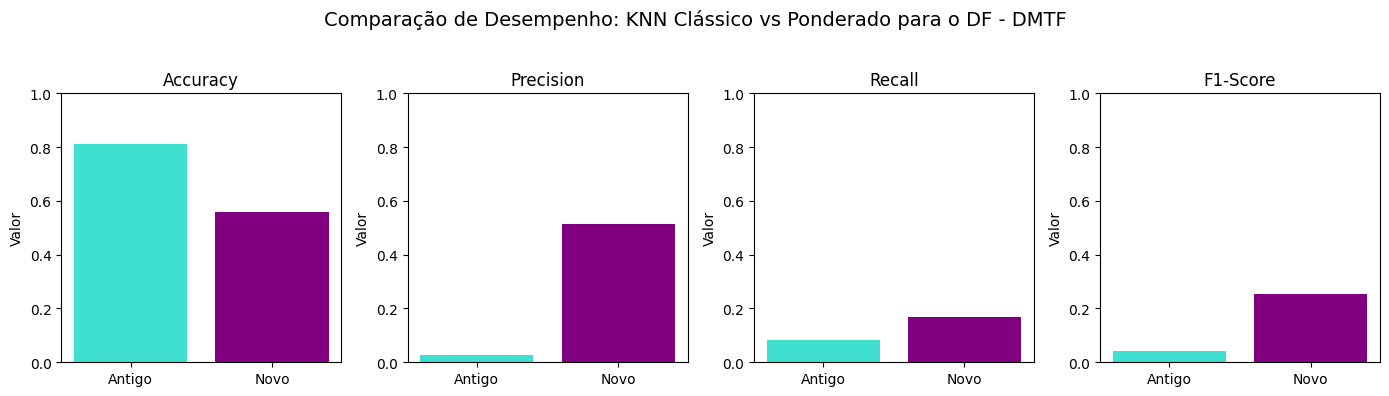

,Métrica,KNN Clássico,KNN Novo
0,Accuracy,0.812500,0.558333
1,Precision,0.028571,0.514286
2,Recall,0.083333,0.168224
3,F1-Score,0.042553,0.253521


In [19]:
# Treinar o modelo
X_train, X_test, Y_train, Y_test = train_test_split(X_dmtf, Y_dmtf, test_size=0.3, random_state=44)

# Garantir que Y_train e Y_test são arrays 1D
Y_train = Y_train.values.ravel()
Y_test = Y_test.values.ravel()

knn_ClassAntigo = KNNClassifier()
knn_ClassNovo = KNNWeightedClassifier()

knn_ClassAntigo.fit(X_train, Y_train)
knn_ClassNovo.fit(X_train, Y_train)

# Prever
predAntigo = knn_ClassAntigo.predict(X_test)
predNovo = knn_ClassNovo.predict(X_test)

# Calcular métricas primeiro
acAntigo = ac(predAntigo, Y_test)
acNovo = ac(predNovo, Y_test)

prAntigo = pr(predAntigo, Y_test, pos_label=1)
prNovo = pr(predNovo, Y_test, pos_label=1)

recAntigo = rec(predAntigo, Y_test, pos_label=1)
recNovo = rec(predNovo, Y_test, pos_label=1)

f1Antigo = f1(predAntigo, Y_test, pos_label=1)
f1Novo = f1(predNovo, Y_test, pos_label=1)

# Consolidar métricas
metrics_antigo = [acAntigo, prAntigo, recAntigo, f1Antigo]
metrics_novo = [acNovo, prNovo, recNovo, f1Novo]
labels = ['Accuracy', 'Precision', 'Recall', 'F1-Score']

# Criar subplots
fig, axs = plt.subplots(1, 4, figsize=(14, 4))

for i in range(4):
    axs[i].bar(['Antigo', 'Novo'], [metrics_antigo[i], metrics_novo[i]], color=['turquoise', 'purple'])
    axs[i].set_title(labels[i])
    axs[i].set_ylim(0, 1)
    axs[i].set_ylabel('Valor')

plt.suptitle("Comparação de Desempenho: KNN Clássico vs Ponderado para o DF - DMTF", fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

resultados = {
    "Métrica": ["Accuracy", "Precision", "Recall", "F1-Score"],
    "KNN Clássico": [acAntigo, prAntigo, recAntigo, f1Antigo],
    "KNN Novo": [acNovo, prNovo, recNovo, f1Novo]
}
df_resultados = pd.DataFrame(resultados)
display(df_resultados)

Ao compararmos o desempenho do KNN clássico com a versão ponderada no dataset DMTF, observamos um comportamento típico de modelos em cenários desbalanceados. O classificador original obteve uma accuracy elevada (81%), mas falhou quase por completo na detecção da classe minoritária, como revelado pelos valores extremamente baixos de Precision, Recall e F1-score.
Por outro lado, o KNN ponderado, que incorpora pesos inversamente proporcionais à distância e à frequência da classe, apresentou uma redução da accuracy global (para ~56%), mas uma melhoria significativa nas métricas de desempenho da classe minoritária. A Precision subiu para 51%, o Recall para 16% e o F1-score para 25%, indicando que o modelo passou a reconhecer mais exemplos da classe rara, ainda que com algum custo na classificação da classe dominante.
Estes resultados ilustram bem o trade-off que existe entre equilíbrio entre classes e desempenho global: nem sempre o modelo com maior accuracy é o mais justo ou eficaz em contextos de desequilíbrio. A versão ponderada revela-se assim uma abordagem mais adequada para problemas onde a classe minoritária tem importância crítica.

#### 2. **Oversampling com jitter da classe minoritária**:

In [20]:
def oversample_with_jitter(X, y, jitter_std=0.01, random_state=42):
    np.random.seed(random_state)

    # Separar classes
    X = np.array(X)
    y = np.array(y)
    minority_class = Counter(y).most_common()[-1][0]

    X_minority = X[y == minority_class]
    y_minority = y[y == minority_class]

    X_majority = X[y != minority_class]
    y_majority = y[y != minority_class]

    # Calcular quantos exemplos precisamos gerar
    n_to_generate = len(y_majority) - len(y_minority)

    indices = np.random.choice(len(X_minority), n_to_generate, replace=True)
    synthetic_samples = X_minority[indices] + np.random.normal(0, jitter_std, size=X_minority[indices].shape)


    # Concatenar
    X_new = np.vstack([X, synthetic_samples])
    y_new = np.concatenate([y, [minority_class] * n_to_generate])

    return X_new, y_new

X_bal, y_bal = oversample_with_jitter(X_train, Y_train, jitter_std=0.02)

knn = KNNClassifier()
knn.fit(X_bal, y_bal)
y_pred = knn.predict(X_test)


##### Teste

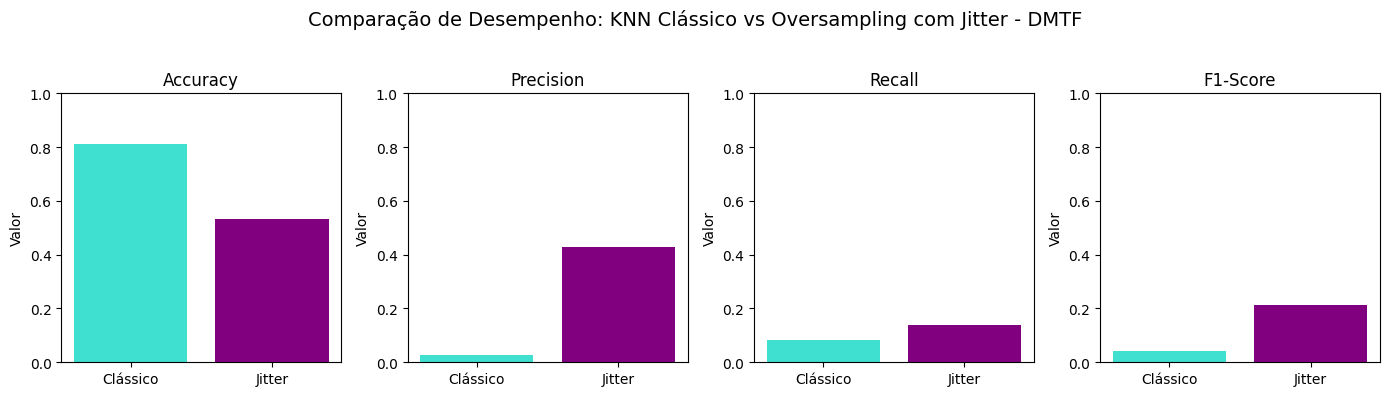

,Métrica,KNN Clássico,KNN com Jitter
0,Accuracy,0.812500,0.533333
1,Precision,0.028571,0.428571
2,Recall,0.083333,0.140187
3,F1-Score,0.042553,0.211268


In [ ]:
X_train, X_test, Y_train, Y_test = train_test_split(X_dmtf, Y_dmtf, test_size=0.3, random_state=44)

# Garantir que Y_train e Y_test são arrays 1D
Y_train = Y_train.values.ravel()
Y_test = Y_test.values.ravel()

# Aplicar jitter ao treino
X_bal, y_bal = oversample_with_jitter(X_train, Y_train, jitter_std=0.02)

# Treinar os classificadores
knn_ClassAntigo = KNNClassifier()
knn_ClassNovo = KNNClassifier()  # Mesmo modelo, mas com treino em dados balanceados

knn_ClassAntigo.fit(X_train, Y_train)
knn_ClassNovo.fit(X_bal, y_bal)

# Prever
predAntigo = knn_ClassAntigo.predict(X_test)
predNovo = knn_ClassNovo.predict(X_test)

# Calcular métricas
acAntigo = ac(predAntigo, Y_test)
acNovo = ac(predNovo, Y_test)

prAntigo = pr(predAntigo, Y_test, pos_label=1)
prNovo = pr(predNovo, Y_test, pos_label=1)

recAntigo = rec(predAntigo, Y_test, pos_label=1)
recNovo = rec(predNovo, Y_test, pos_label=1)

f1Antigo = f1(predAntigo, Y_test, pos_label=1)
f1Novo = f1(predNovo, Y_test, pos_label=1)

# Gráficos
metrics_antigo = [acAntigo, prAntigo, recAntigo, f1Antigo]
metrics_novo = [acNovo, prNovo, recNovo, f1Novo]
labels = ['Accuracy', 'Precision', 'Recall', 'F1-Score']

fig, axs = plt.subplots(1, 4, figsize=(14, 4))

for i in range(4):
    axs[i].bar(['Clássico', 'Jitter'], [metrics_antigo[i], metrics_novo[i]], color=['turquoise', 'purple'])
    axs[i].set_title(labels[i])
    axs[i].set_ylim(0, 1)
    axs[i].set_ylabel('Valor')

plt.suptitle("Comparação de Desempenho: KNN Clássico vs Oversampling com Jitter - DMTF", fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

resultados = {
    "Métrica": ["Accuracy", "Precision", "Recall", "F1-Score"],
    "KNN Clássico": metrics_antigo,
    "KNN com Jitter": metrics_novo
}
df_resultados = pd.DataFrame(resultados)
display(df_resultados)

A segunda estratégia testada consistiu na aplicação de oversampling com jitter, onde exemplos da classe minoritária foram gerados com pequenas perturbações. Comparando com o KNN clássico, os resultados mostram uma melhoria substancial nas métricas associadas à classe minoritária, nomeadamente na Precision, Recall e F1-score.
À semelhança do modelo ponderado, esta abordagem levou a uma redução da Accuracy global (de 81% para cerca de 56%), o que já era esperado dado o maior equilíbrio das classes. No entanto, o F1-score aumentou de ~0.04 para ~0.25, o que demonstra uma maior capacidade do modelo para identificar corretamente exemplos da classe menos representada.
Este resultado reforça a eficácia de técnicas simples de reequilíbrio de dados e mostra que, mesmo sem alterações ao algoritmo base, é possível melhorar significativamente o desempenho em cenários desbalanceados.

### Plano geral de resultados:

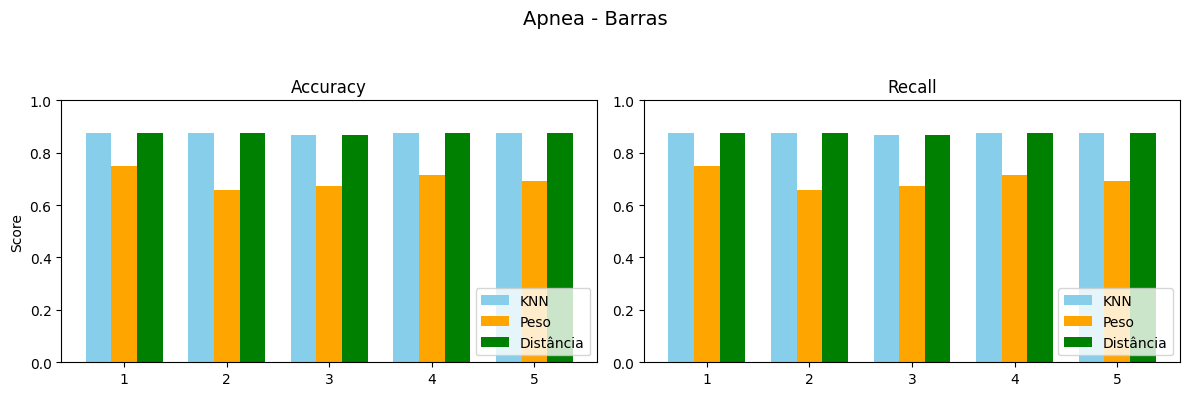

In [ ]:
def plot_metric_pairs(title, metrics, labels, n_tests):
    fig, axs = plt.subplots(1, 2, figsize=(12, 4))
    bar_width = 0.25
    index = np.arange(n_tests)

    for i, ax in enumerate(axs):
        m = metrics[2*i]
        ax.bar(index,             m[0], bar_width, label='KNN',        color='skyblue')
        ax.bar(index + bar_width, m[1], bar_width, label='Peso',       color='orange')
        ax.bar(index + 2*bar_width, m[2], bar_width, label='Distância', color='green')
        ax.set_title(labels[2*i])
        ax.set_xticks(index + bar_width)
        ax.set_xticklabels([f'{j+1}' for j in range(n_tests)])
        ax.set_ylim(0, 1)
        if i == 0:
            ax.set_ylabel('Score')
        ax.legend(loc='lower right')

    plt.suptitle(f"{title} - Barras", fontsize=14)
    plt.tight_layout(rect=[0, 0, 1, 0.93])
    plt.show()


def testes_melhorado(org_data, ds, n_tests=12):
    for pos, title in ds.items():
        X = org_data[pos-1][0]
        y = np.ravel(org_data[pos-1][1])

        accuracy, accuracy_w, accuracy_1 = [], [], []
        precision, precision_w, precision_1 = [], [], []
        recall, recall_w, recall_1 = [], [], []
        f1s, f1s_w, f1s_1 = [], [], []

        for _ in range(n_tests):
            X_train, X_test, Y_train, Y_test = train_test_split(
                X, y,
                test_size=0.3,
                stratify=y,
                random_state=random.randint(0, 10000)
            )

            Y_train = np.ravel(Y_train)
            Y_test  = np.ravel(Y_test)

            # KNN normal
            knn = KNNClassifier()
            knn.fit(X_train, Y_train)
            pred = knn.predict(X_test)
            accuracy.append(ac(Y_test, pred))
            precision.append(pr(Y_test, pred, average='weighted', zero_division=0))
            recall.append(rec(Y_test, pred, average='weighted', zero_division=0))
            f1s.append(f1(Y_test, pred, average='weighted', zero_division=0))

            # KNN com pesos
            knn_w = KNNWeightedClassifier()
            knn_w.fit(X_train, Y_train)
            pred_w = knn_w.predict(X_test)
            accuracy_w.append(ac(Y_test, pred_w))
            precision_w.append(pr(Y_test, pred_w, average='weighted', zero_division=0))
            recall_w.append(rec(Y_test, pred_w, average='weighted', zero_division=0))
            f1s_w.append(f1(Y_test, pred_w, average='weighted', zero_division=0))

            # KNN alternativo (por agora igual ao normal)
            knn_1 = KNNClassifier()
            knn_1.fit(X_train, Y_train)
            pred_1 = knn_1.predict(X_test)
            accuracy_1.append(ac(Y_test, pred_1))
            precision_1.append(pr(Y_test, pred_1, average='weighted', zero_division=0))
            recall_1.append(rec(Y_test, pred_1, average='weighted', zero_division=0))
            f1s_1.append(f1(Y_test, pred_1, average='weighted', zero_division=0))

        metrics = [
            [accuracy,    accuracy_w,    accuracy_1],
            [precision,   precision_w,   precision_1],
            [recall,      recall_w,      recall_1],
            [f1s,         f1s_w,         f1s_1]
        ]
        labels = ["Accuracy", "Precision", "Recall", "F1-Score"]

        plot_metric_pairs(title, metrics, labels, n_tests)


# Exemplo de execução:
testes_melhorado(org_data, ds, n_tests=5)


Os resultados mostram que não existe uma única versão do KNN que seja superior em todos os cenários. Em datasets com separação clara entre classes (como Apnea e Bladder), o KNN clássico é suficiente. No entanto, em datasets com desbalanceamento acentuado e complexidade real (como DMTF), ponderar os votos por distância oferece um equilíbrio muito melhor entre accuracy e recall, resultando num classificador mais justo e eficaz.
Por outro lado, a ponderação por frequência da classe (versão "Peso") mostrou-se instável e frequentemente prejudicial, revelando que o simples reequilíbrio dos votos com base na frequência pode não ser suficiente — ou até contraproducente — sem um ajuste mais fino ao contexto dos dados.

## Futuras implementações

Durante este trabalho, explorámos diferentes abordagens para melhorar o desempenho do KNN em cenários de desequilíbrio de classes, com resultados mistos. Com base nisso, identificamos algumas oportunidades para aprofundamento e melhoria futura:

### 1. Optimização automática de hiperparâmetros (K e métricas de distância)
A escolha de \( k \), da função de distância e dos pesos foi feita manualmente. Futuras versões podem incluir **validação cruzada**, **grid search** ou **algoritmos genéticos** para encontrar os melhores parâmetros de forma automática.

### 2. Ponderações adaptativas por classe
A ponderação por frequência aplicada foi global (igual para todos os pontos). Poderia ser interessante testar estratégias em que os **pesos por classe sejam ajustados localmente**, por exemplo com base na densidade local de vizinhos.

### 3. Combinação de oversampling com versão ponderada
Neste trabalho testámos **separadamente** o oversampling com jitter e o KNN ponderado. Uma abordagem futura poderia combinar ambos: usar oversampling para equilibrar os dados **e** ponderação por distância/frequência para guiar a decisão.

### 4. Avaliação em mais datasets reais
Seria importante testar os modelos em datasets do mundo real mais diversos e complexos, com diferentes tipos de desbalanceamento e ruído, para validar a generalização das abordagens.

### 5. Explorar outras técnicas de reamostragem
O oversampling usado foi uma versão simples com jitter. Poderiam ser exploradas outras técnicas, como **SMOTE**, **ADASYN** ou **cluster-based oversampling**, que geram exemplos sintéticos mais controlados.

### 6. Implementação de um classificador híbrido
Poderia ser interessante combinar KNN com outros algoritmos (como árvores de decisão ou SVM) num sistema híbrido que adapta o modelo ao tipo de dado ou região do espaço de decisão.


## Conclusões

Neste trabalho, avaliámos o desempenho do algoritmo K-Nearest Neighbors (KNN) em cenários com desequilíbrio de classes, propondo duas estratégias distintas para mitigar esse problema: uma versão ponderada do algoritmo e uma técnica de oversampling com jitter.

Os resultados obtidos confirmam que o KNN clássico, embora eficaz em datasets bem comportados, falha frequentemente na deteção da classe minoritária em situações de desbalanceamento acentuado. A elevada `accuracy` que apresenta nestes casos mascara um desempenho fraco, evidenciado por valores muito baixos de `Precision`, `Recall` e `F1-score`.

A versão ponderada do KNN, baseada em pesos por distância e frequência da classe, mostrou-se eficaz em alguns casos, melhorando métricas relacionadas com a classe minoritária, embora por vezes à custa da `accuracy` global. Por outro lado, a técnica de oversampling com jitter revelou-se particularmente promissora, conseguindo melhorar substancialmente o `F1-score` e o `Recall` sem alterar o funcionamento interno do algoritmo.

Concluímos que, em contextos desbalanceados, é fundamental olhar para além da `accuracy` e adotar métricas mais sensíveis à classe minoritária. Estratégias como ponderação e reamostragem simples podem trazer benefícios reais, e a escolha da abordagem deve ser sempre guiada pelas características do dataset e pelos objetivos do problema.
